In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt

import robomimic.dev.hparam.utils.demo_utils as demo_utils
import robomimic.dev.hparam.utils.pkl_utils as pkl_utils
import robomimic.dev.hparam.utils.stat_utils as stat_utils
import robomimic.dev.hparam.utils.plot_utils as plot_utils

import robomimic.dev.hparam.metrics.metric_fn as Metrics
from robomimic.dev.hparam.eval_suite import DemoEvalSuite

In [23]:
pkl_path = "/home/wjung85/Repo/projects/FastIL/logs/hparam_debug_sparc/square_image_action_horizon_16_additional_bl_iter_0_2025-01-20 20:06:48.958704.pkl"
demo = pkl_utils.load_demo_from_pkl(pkl_path, demo_idx = 0)

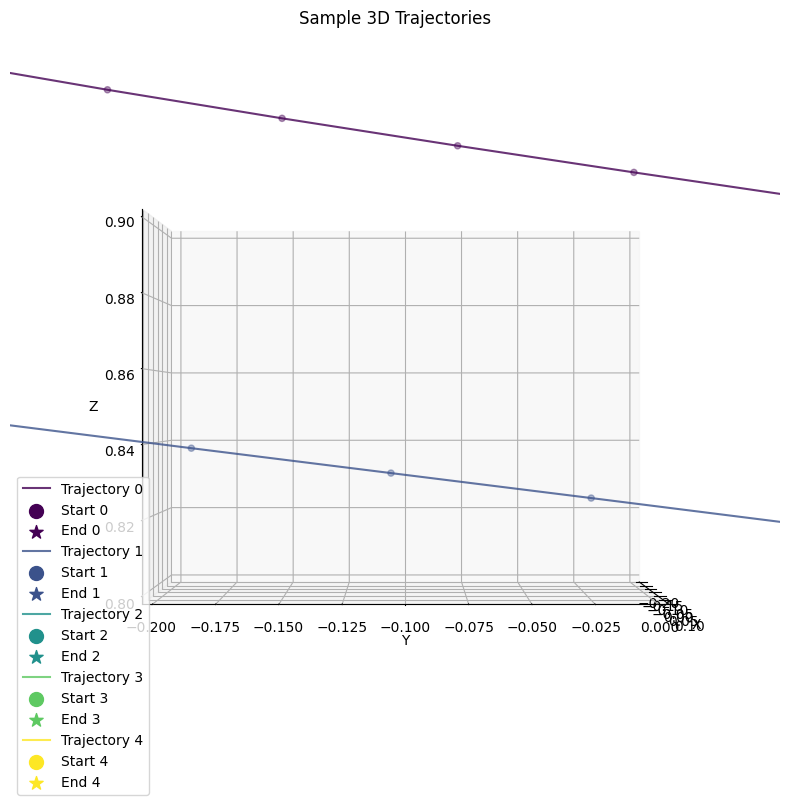

In [92]:
def visualize_3d_trajectories(trajectories: torch.Tensor, 
                            title: str = "3D Trajectories",
                            alpha: float = 0.6,
                            figsize: tuple = (10, 10),
                            show_dots: bool = True,
                            colormap: str = 'viridis',
                            elev=0,
                            azim=0) -> None:
    """Visualize multiple 3D trajectories.
    
    Args:
        trajectories: Tensor of shape (B, T, 3) where:
            B: number of trajectories
            T: number of timesteps
            3: (x, y, z) coordinates
        title: Plot title
        alpha: Transparency of trajectories
        figsize: Figure size
        show_dots: Whether to show points along trajectory
        colormap: Colormap for different trajectories
    """
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    
    # Convert to numpy if tensor
    if torch.is_tensor(trajectories):
        trajectories = trajectories.detach().cpu().numpy()
    
    # Create figure
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    
    # Get colormap
    colors = plt.cm.get_cmap(colormap)(np.linspace(0, 1, trajectories.shape[0]))
    
    # Plot each trajectory
    for i, traj in enumerate(trajectories):
        # Extract x, y, z coordinates
        x, y, z = traj[:, 0], traj[:, 1], traj[:, 2]
        
        # Plot line
        ax.plot(x, y, z, 
               color=colors[i], 
               alpha=alpha, 
               label=f'Trajectory {i}')
        
        # Plot points if requested
        if show_dots:
            ax.scatter(x, y, z, 
                      color=colors[i], 
                      alpha=alpha*0.5, 
                      s=20)
        
        # Plot start and end points
        ax.scatter(x[0], y[0], z[0], 
                  color=colors[i], 
                  marker='o', 
                  s=100, 
                  label=f'Start {i}')
        ax.scatter(x[-1], y[-1], z[-1], 
                  color=colors[i], 
                  marker='*', 
                  s=100, 
                  label=f'End {i}')
    
    # Set labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    ax.set_xlim(-0.2, 0.1)
    ax.set_ylim(-0.2, 0.0)
    ax.set_zlim(0.8, 0.9)
    # Add legend
    ax.legend()
    
    # Make the plot more viewable
    ax.view_init(elev=elev, azim=azim)
    
    # Show grid
    ax.grid(True)
    
    plt.show()

# Example usage:
if __name__ == "__main__":
    # Generate sample trajectories
    B, T = 5, 100  # 5 trajectories, 100 timesteps each
    
    # Create some sample spiral trajectories
    t = np.linspace(0, 10, T)
    trajectories = []
    
    for i in range(B):
        # Create a spiral with different radius and height for each trajectory
        radius = 1 + 0.2 * i
        height = 0.5 * i
        x = radius * np.cos(t)
        y = radius * np.sin(t)
        z = height + t/10
        
        traj = np.stack([x, y, z], axis=1)
        trajectories.append(traj)
    
    trajectories = np.stack(trajectories, axis=0)
    
    # Visualize
    visualize_3d_trajectories(
        trajectories,
        title="Sample 3D Trajectories",
        alpha=0.8,
        show_dots=True
    )

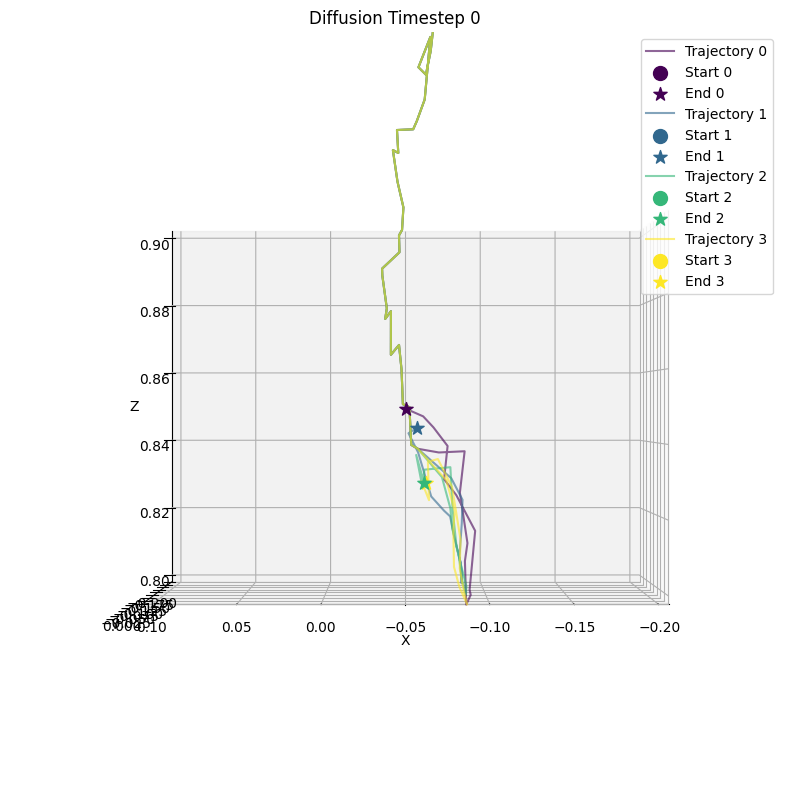

In [97]:
pred_idx = 3

# (TD, TH, 3)
diffusion_timesteps = list(demo["diffusion_logs"][pred_idx].keys())

positions_list = []
for diffusion_timestep in diffusion_timesteps:
    actions   = demo["diffusion_logs"][pred_idx][diffusion_timestep]["loss_log"]["actions_all"][0]
    positions = actions[:, :3].detach().cpu().numpy()
    positions_list.append(positions)

positions = np.stack(positions_list, axis=0)

visualize_3d_trajectories(
    positions[::3],
    title=f"Diffusion Timestep {diffusion_timestep}",
    alpha=0.6,
    show_dots=False,
    colormap="viridis",
    elev=0,
    azim=90
)

In [62]:
positions[:, :, 0].max()

-0.25272954

In [72]:
demo["diffusion_logs"][3][90]["loss_log"]["actions"].shape

torch.Size([1, 31, 8])

In [27]:
list(demo["diffusion_logs"][3].keys())

[90, 80, 70, 60, 50, 40, 30, 20, 10, 0]

In [ ]:
def get_diffusion_actions(demo, action_idx, pred_idx):
    actions = demo["diffusion_logs"][action_idx][pred_idx]["loss_log"]["actions"]
    return actions